C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\812973313.py:120: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\812973313.py:123: RuntimeWarning: All-NaN slice encountered
  sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)


Available bathymetry items:
0 


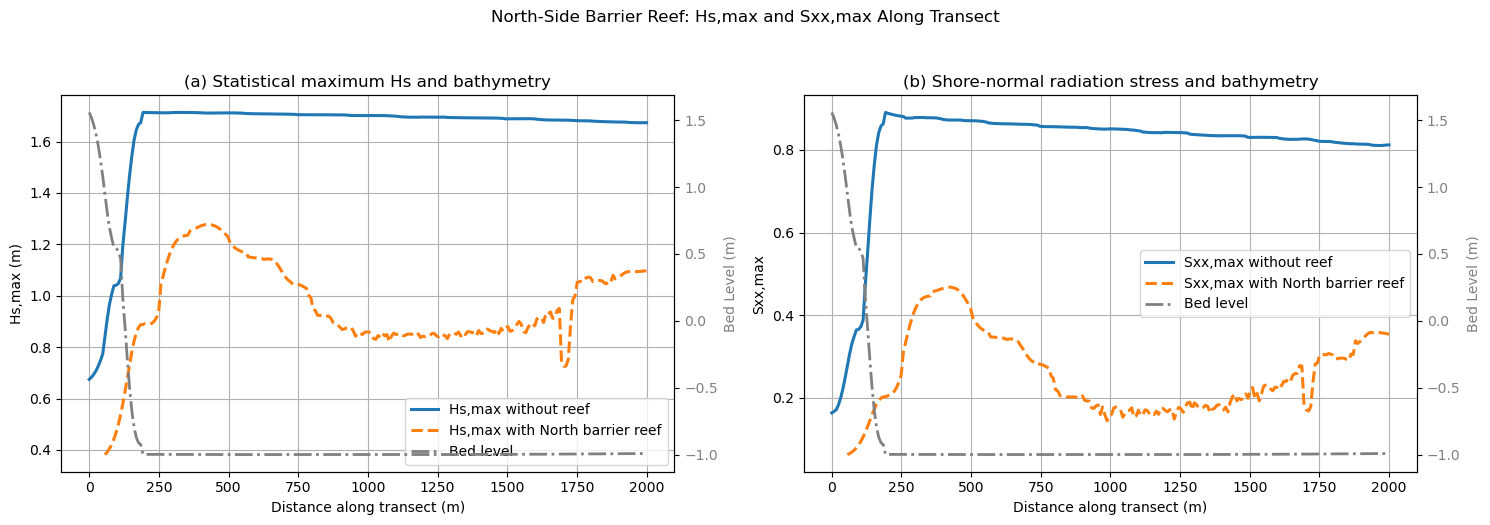

In [8]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732150, 3178930
x2, y2 = 732988, 3177114

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


def extract_bathy_profile(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bathy_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bathy_profile

# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Bathymetry
bed_level = extract_bathy_profile(
    bathy_dfsu,
    item=0
)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + bathymetry
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_bathy = ax_hs.twinx()

ax_hs_bathy.plot(
    distance,
    bed_level,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Bed level"
)

ax_hs_bathy.set_ylabel("Bed Level (m)", color="gray")
ax_hs_bathy.tick_params(axis="y", labelcolor="gray")

# Optional: invert bathymetry axis
# ax_hs_bathy.invert_yaxis()

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_bathy.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and bathymetry")

# -------------------------
# Panel (b): Sxx,max + bathymetry
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_bathy = ax_sxx.twinx()

ax_sxx_bathy.plot(
    distance,
    bed_level,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Bed level"
)

ax_sxx_bathy.set_ylabel("Bed Level (m)", color="gray")
ax_sxx_bathy.tick_params(axis="y", labelcolor="gray")

# Optional: invert bathymetry axis
# ax_sxx_bathy.invert_yaxis()

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_bathy.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and bathymetry")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\2954038689.py:120: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\2954038689.py:123: RuntimeWarning: All-NaN slice encountered
  sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)


Available bathymetry items:
0 


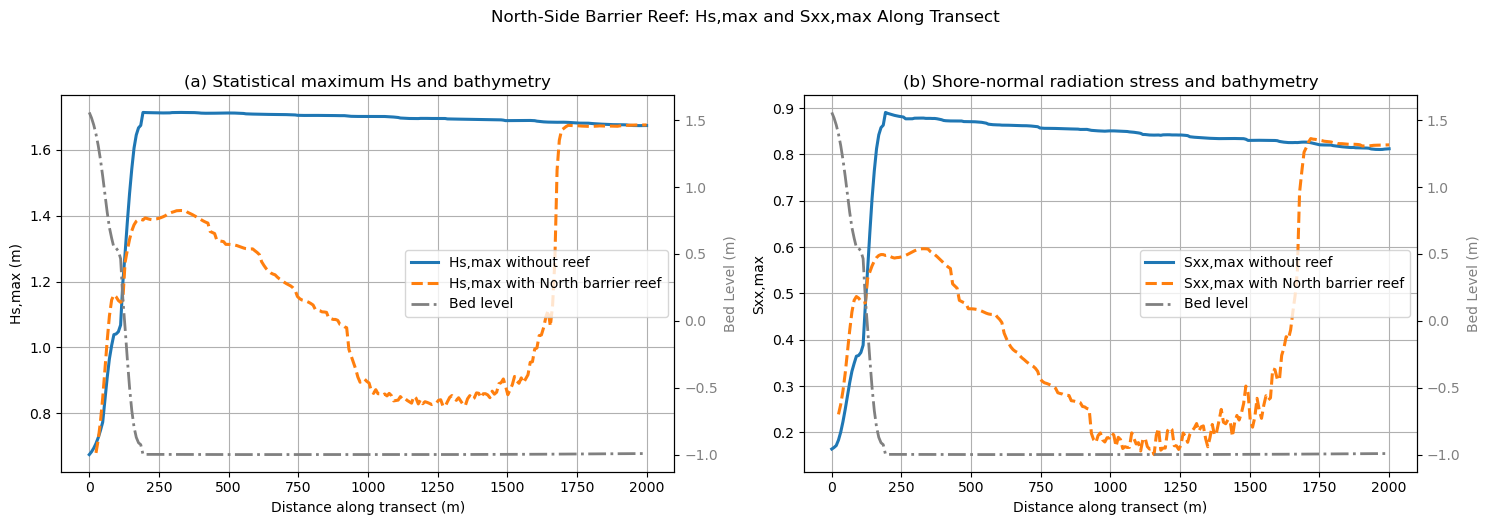

In [14]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_v1.sw - Result Files\Northside_barrier_reef_v1.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732150, 3178930
x2, y2 = 732988, 3177114

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


def extract_bathy_profile(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bathy_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bathy_profile

# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Bathymetry
bed_level = extract_bathy_profile(
    bathy_dfsu,
    item=0
)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + bathymetry
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_bathy = ax_hs.twinx()

ax_hs_bathy.plot(
    distance,
    bed_level,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Bed level"
)

ax_hs_bathy.set_ylabel("Bed Level (m)", color="gray")
ax_hs_bathy.tick_params(axis="y", labelcolor="gray")

# Optional: invert bathymetry axis
# ax_hs_bathy.invert_yaxis()

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_bathy.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and bathymetry")

# -------------------------
# Panel (b): Sxx,max + bathymetry
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_bathy = ax_sxx.twinx()

ax_sxx_bathy.plot(
    distance,
    bed_level,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Bed level"
)

ax_sxx_bathy.set_ylabel("Bed Level (m)", color="gray")
ax_sxx_bathy.tick_params(axis="y", labelcolor="gray")

# Optional: invert bathymetry axis
# ax_sxx_bathy.invert_yaxis()

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_bathy.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and bathymetry")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 


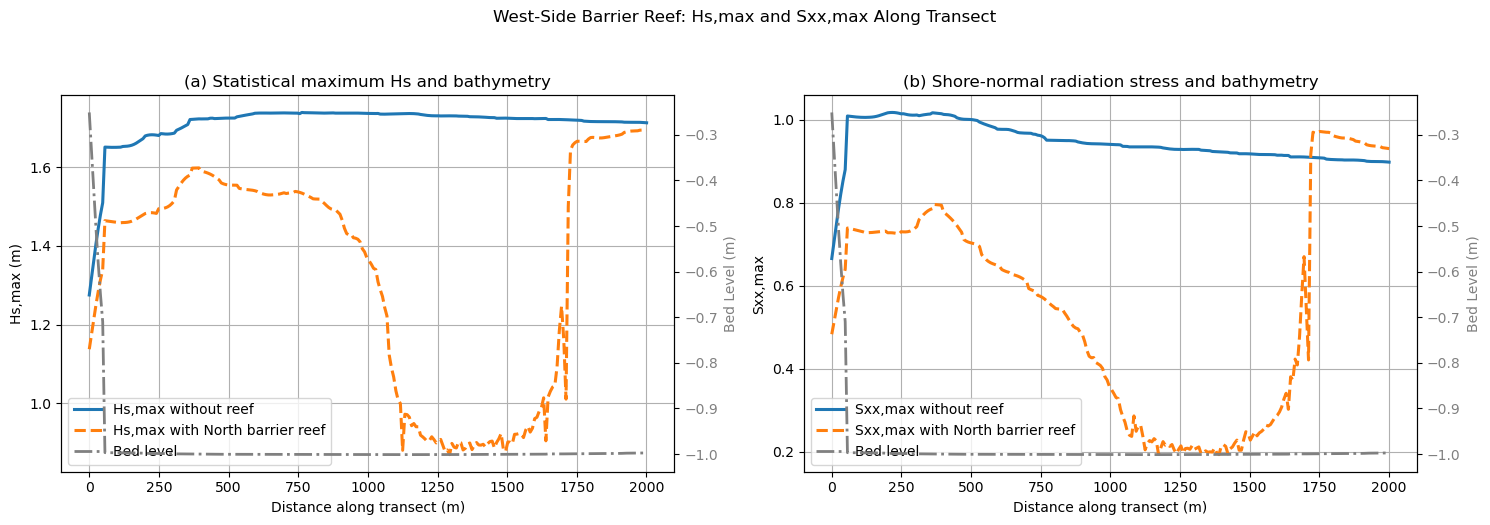

In [6]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# west-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731549, 3175813

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


def extract_bathy_profile(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bathy_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bathy_profile

# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Bathymetry
bed_level = extract_bathy_profile(
    bathy_dfsu,
    item=0
)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + bathymetry
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_bathy = ax_hs.twinx()

ax_hs_bathy.plot(
    distance,
    bed_level,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Bed level"
)

ax_hs_bathy.set_ylabel("Bed Level (m)", color="gray")
ax_hs_bathy.tick_params(axis="y", labelcolor="gray")

# Optional: invert bathymetry axis
# ax_hs_bathy.invert_yaxis()

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_bathy.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and bathymetry")

# -------------------------
# Panel (b): Sxx,max + bathymetry
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_bathy = ax_sxx.twinx()

ax_sxx_bathy.plot(
    distance,
    bed_level,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Bed level"
)

ax_sxx_bathy.set_ylabel("Bed Level (m)", color="gray")
ax_sxx_bathy.tick_params(axis="y", labelcolor="gray")

# Optional: invert bathymetry axis
# ax_sxx_bathy.invert_yaxis()

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_bathy.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and bathymetry")

plt.suptitle(
    "West-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 


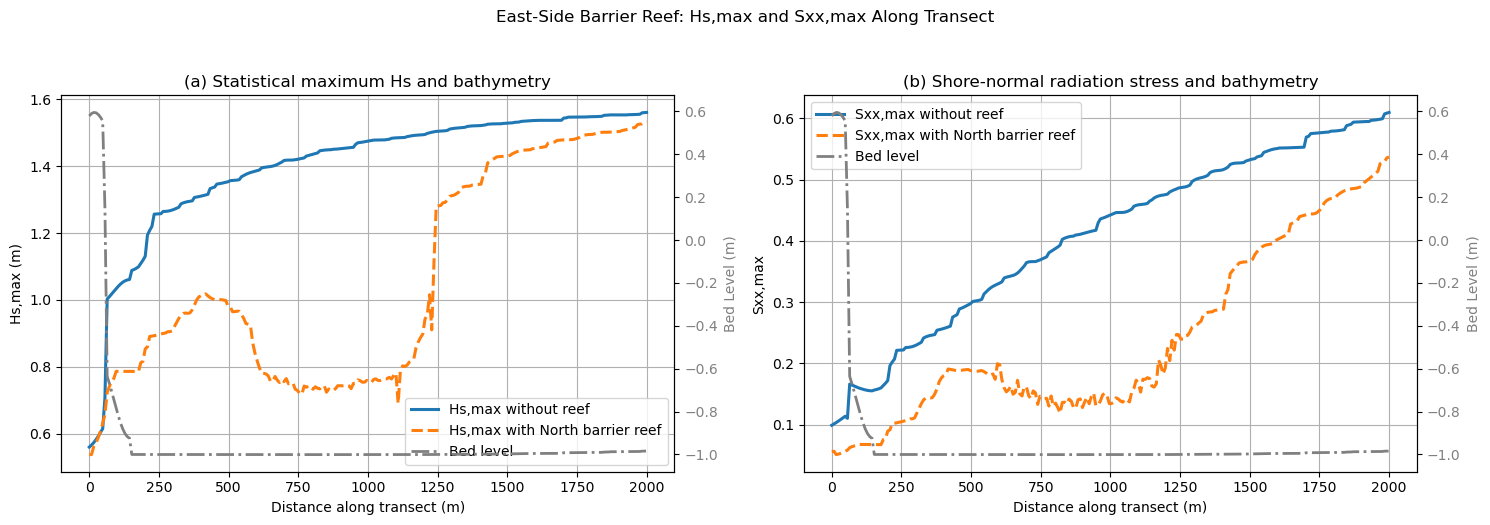

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# west-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 736598, 3177013
x2, y2 = 734827, 3176083

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


def extract_bathy_profile(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bathy_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bathy_profile

# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Bathymetry
bed_level = extract_bathy_profile(
    bathy_dfsu,
    item=0
)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + bathymetry
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_bathy = ax_hs.twinx()

ax_hs_bathy.plot(
    distance,
    bed_level,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Bed level"
)

ax_hs_bathy.set_ylabel("Bed Level (m)", color="gray")
ax_hs_bathy.tick_params(axis="y", labelcolor="gray")

# Optional: invert bathymetry axis
# ax_hs_bathy.invert_yaxis()

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_bathy.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and bathymetry")

# -------------------------
# Panel (b): Sxx,max + bathymetry
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_bathy = ax_sxx.twinx()

ax_sxx_bathy.plot(
    distance,
    bed_level,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Bed level"
)

ax_sxx_bathy.set_ylabel("Bed Level (m)", color="gray")
ax_sxx_bathy.tick_params(axis="y", labelcolor="gray")

# Optional: invert bathymetry axis
# ax_sxx_bathy.invert_yaxis()

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_bathy.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and bathymetry")

plt.suptitle(
    "East-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\3070432350.py:96: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\3070432350.py:99: RuntimeWarning: All-NaN slice encountered
  sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)


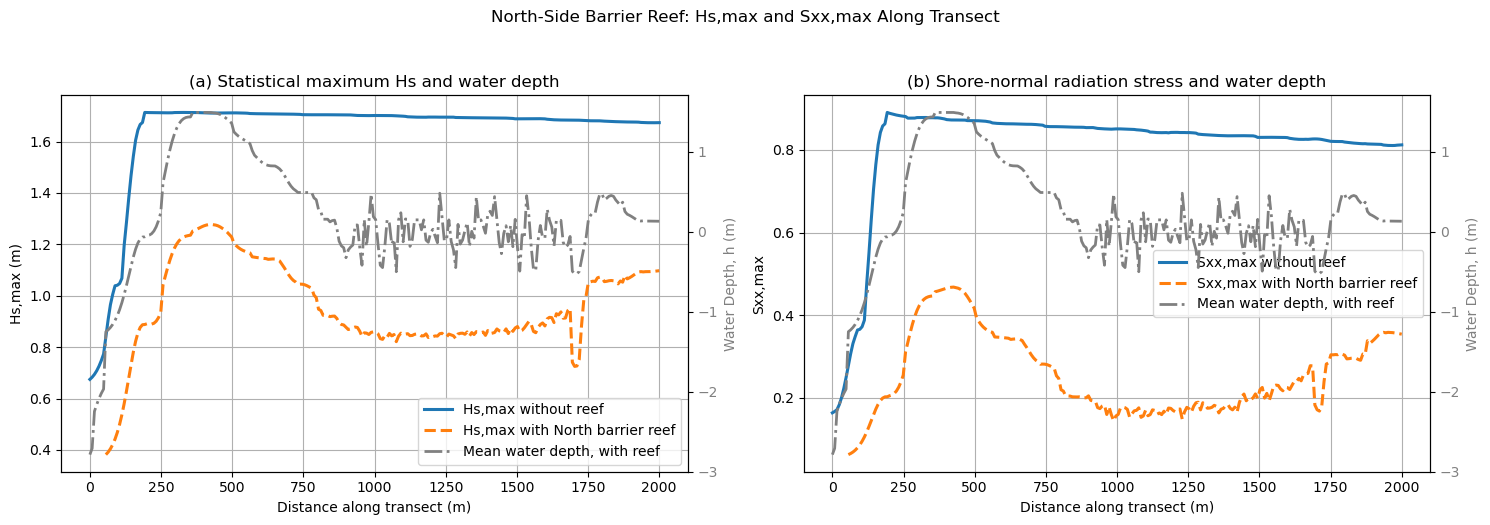

In [10]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\Northside_barrier_reef_v1.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732150, 3178930
x2, y2 = 732988, 3177114

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\2261534929.py:96: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\2261534929.py:99: RuntimeWarning: All-NaN slice encountered
  sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)


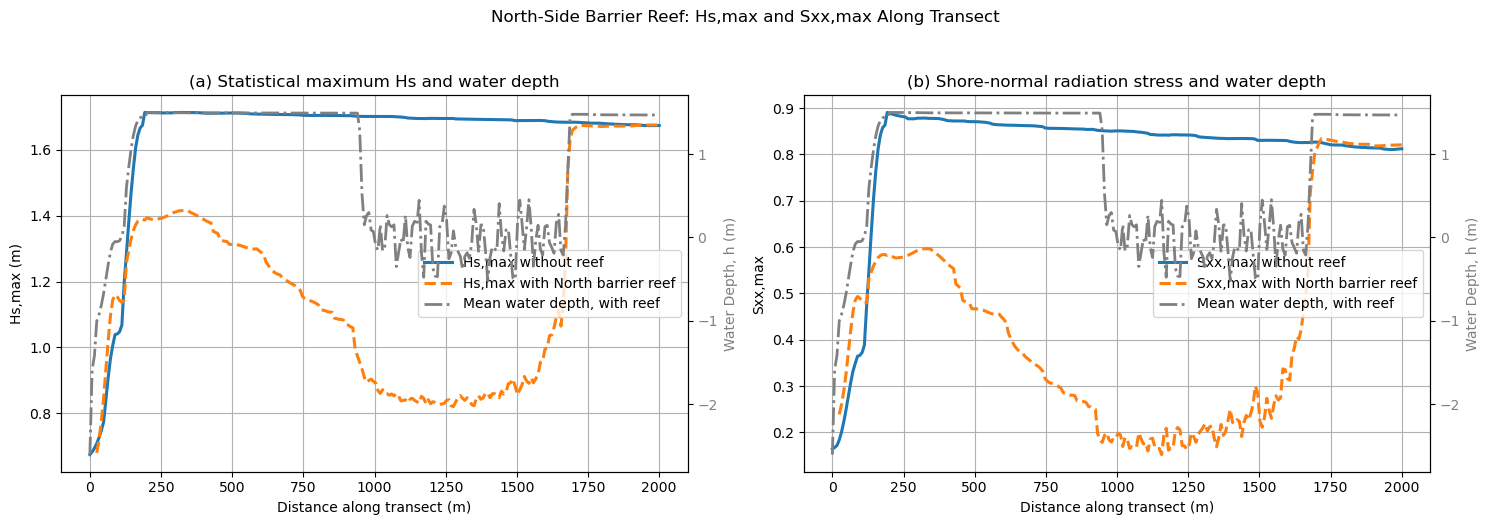

In [15]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_v1.sw - Result Files\Northside_barrier_reef_v1.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732150, 3178930
x2, y2 = 732988, 3177114

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\3063080249.py:96: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\3063080249.py:99: RuntimeWarning: All-NaN slice encountered
  sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)


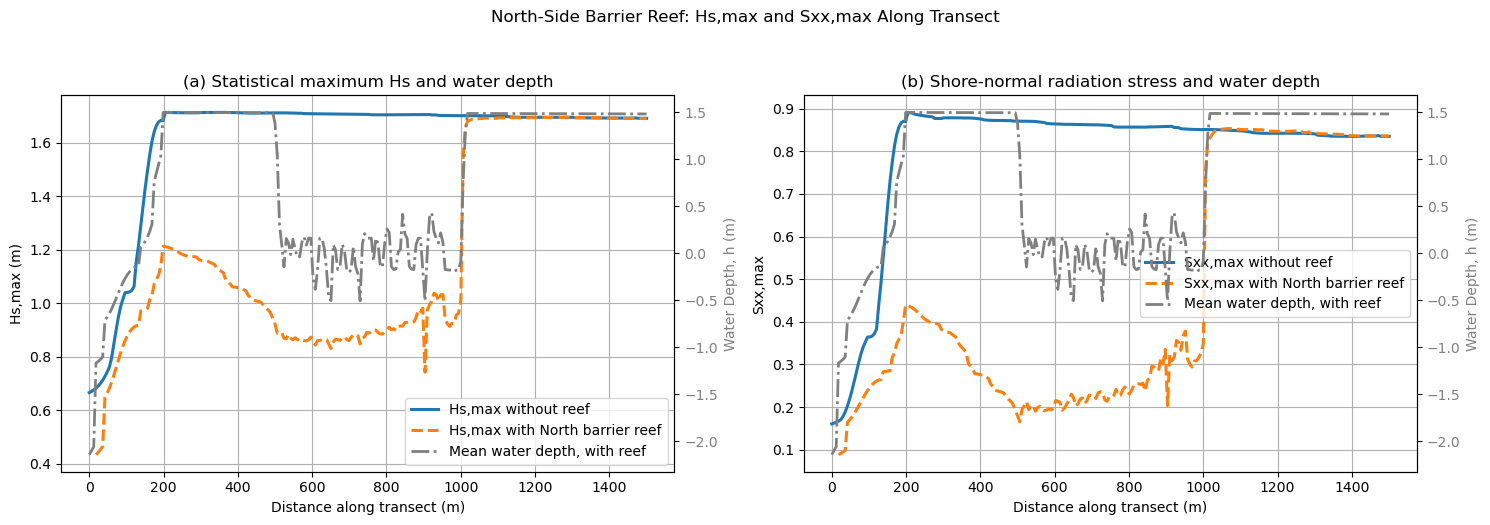

In [17]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_v2.sw - Result Files\Northside_barrier_reef_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732144, 3178938
x2, y2 = 732762, 3177571

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\1681257354.py:96: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_195492\1681257354.py:99: RuntimeWarning: All-NaN slice encountered
  sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)


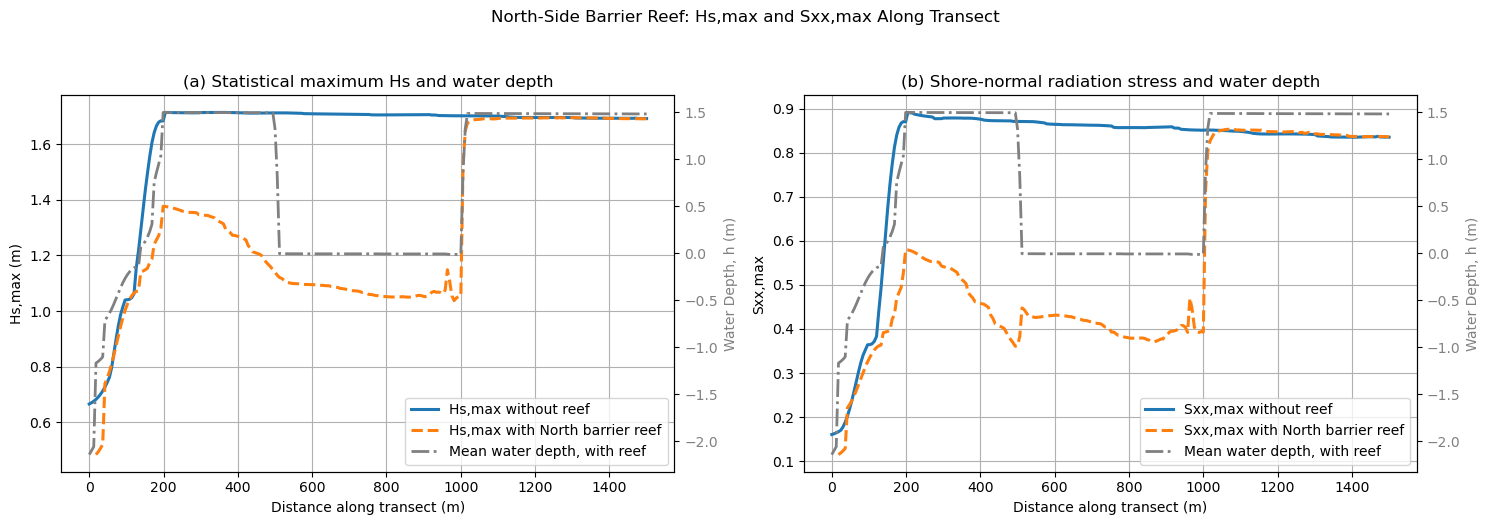

In [22]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732144, 3178938
x2, y2 = 732762, 3177571

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "North-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

C:\Users\sahad2\AppData\Local\Temp\ipykernel_22068\1353944549.py:95: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_22068\1353944549.py:98: RuntimeWarning: All-NaN slice encountered
  sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)


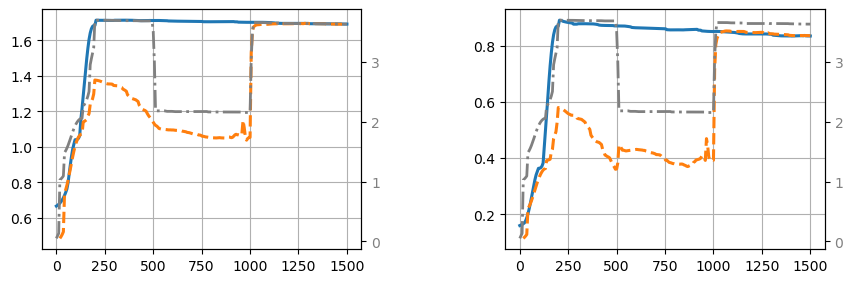

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732144, 3178938
x2, y2 = 732762, 3177571
n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Mean water depth
depth_reef_mean = np.nanmax(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

tick_size = 10

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(9, 3),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------


ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--"
)

ax_hs.grid(True)

# Increase tick text size
ax_hs.tick_params(axis='both', labelsize=tick_size)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-."
)

ax_hs_depth.tick_params(
    axis='y',
    labelsize=tick_size,
    labelcolor='gray'
)

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------

ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--"
)

ax_sxx.grid(True)

# Increase tick text size
ax_sxx.tick_params(axis='both', labelsize=tick_size)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-."
)

ax_sxx_depth.tick_params(
    axis='y',
    labelsize=tick_size,
    labelcolor='gray'
)

# =========================
# Layout
# =========================

plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.15,
    top=0.95,
    wspace=0.45
)

plt.show()

C:\Users\sahad2\AppData\Local\Temp\ipykernel_22068\2408660363.py:98: RuntimeWarning: All-NaN slice encountered
  hsmax_reef = np.nanmax(hs_reef_all, axis=0)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_22068\2408660363.py:101: RuntimeWarning: All-NaN slice encountered
  sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)


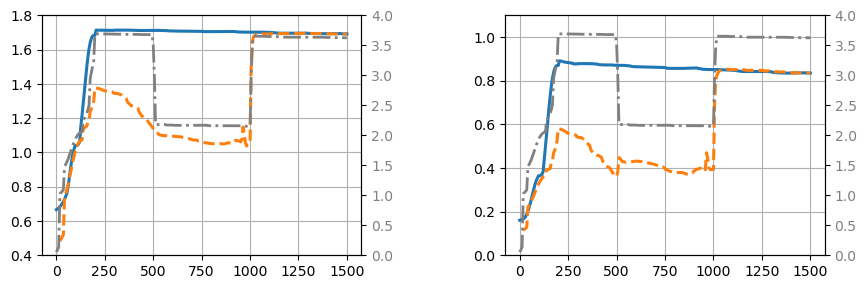

In [10]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732144, 3178938
x2, y2 = 732762, 3177571
n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Significant wave height
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Radiation stress Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# =========================
# Statistical values
# =========================

hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Using max depth, same as your previous code
depth_reef_mean = np.nanmax(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

tick_size = 10

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(9, 3),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------

ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="With reef"
)

ax_hs.set_ylim(0.4, 1.8)
ax_hs.grid(True)
ax_hs.tick_params(axis="both", labelsize=tick_size)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth"
)

ax_hs_depth.set_ylim(0, 4.0)
ax_hs_depth.tick_params(
    axis="y",
    labelsize=tick_size,
    labelcolor="gray"
)

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------

ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="With reef"
)

ax_sxx.set_ylim(0, 1.1)
ax_sxx.grid(True)
ax_sxx.tick_params(axis="both", labelsize=tick_size)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Water depth"
)

ax_sxx_depth.set_ylim(0, 4.0)
ax_sxx_depth.tick_params(
    axis="y",
    labelsize=tick_size,
    labelcolor="gray"
)

# =========================
# Layout
# =========================

plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.15,
    top=0.95,
    wspace=0.45
)

plt.show()

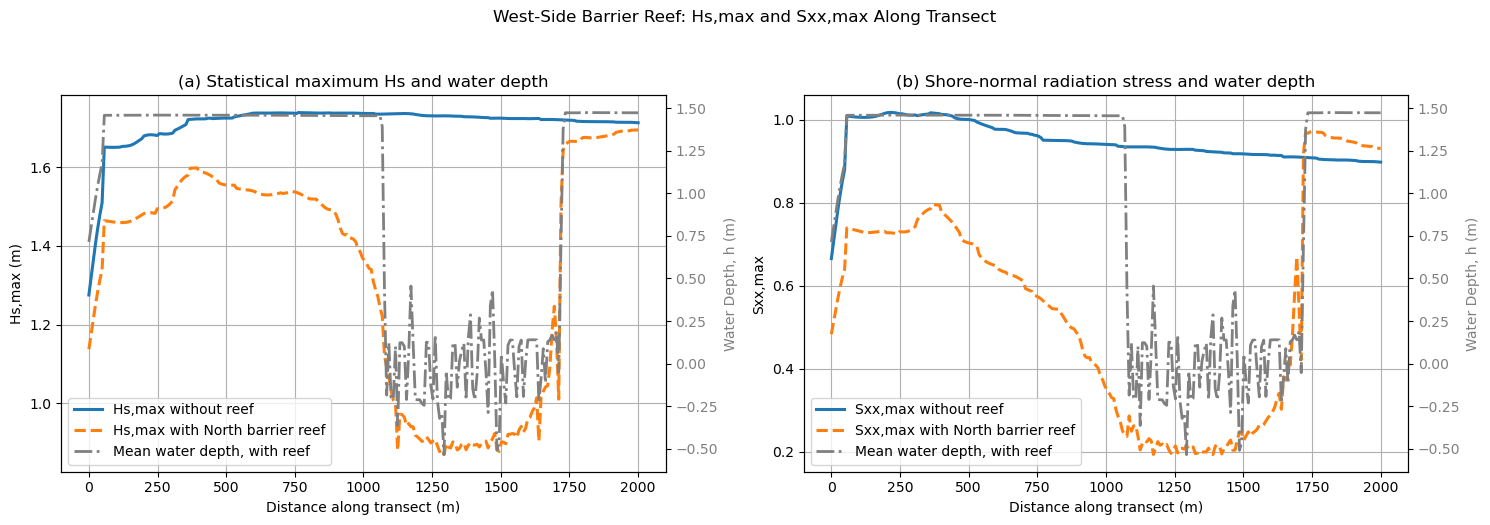

In [11]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731549, 3175813

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "West-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

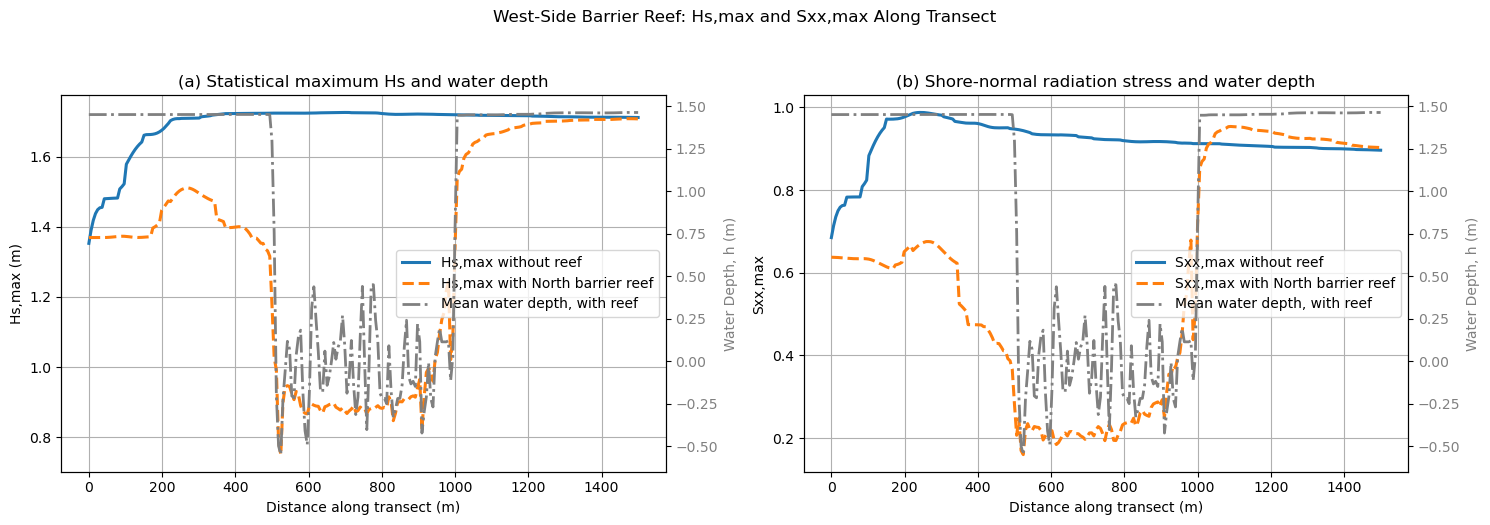

In [16]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_v1.sw - Result Files\west_side_barrier_reef_v1.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "West-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

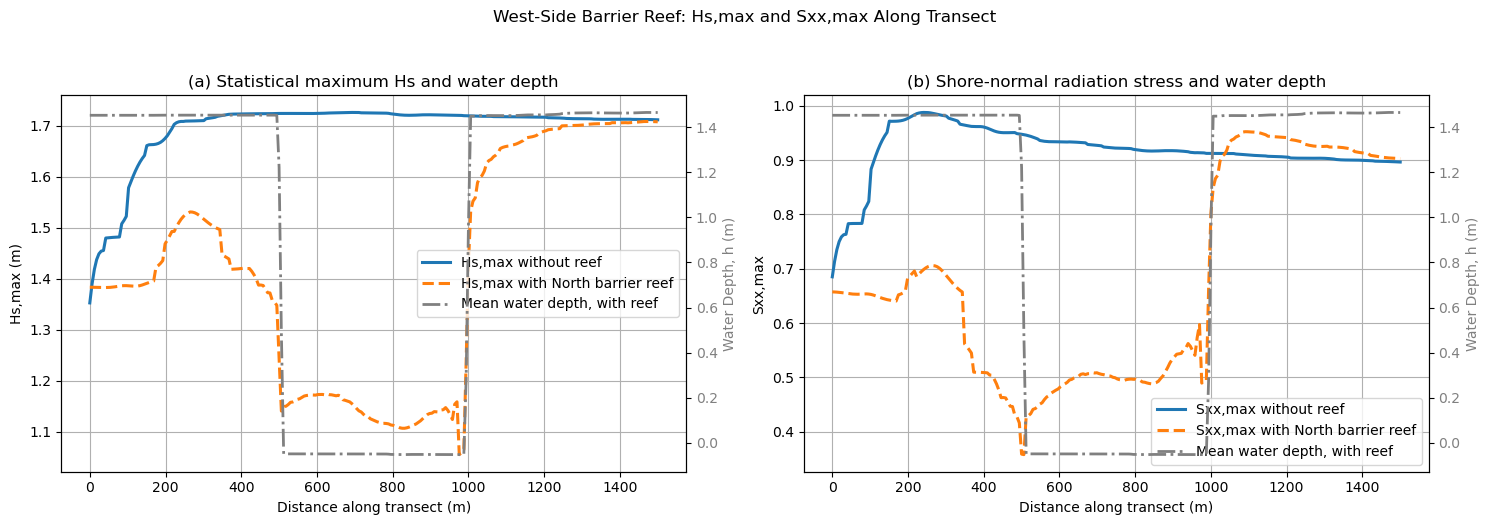

In [21]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "West-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

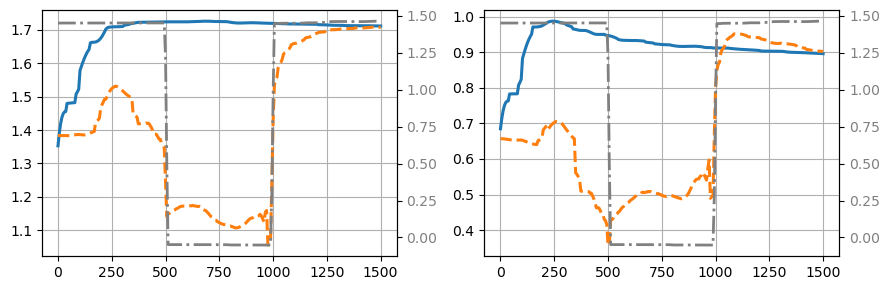

In [2]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(9, 3),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2
    # label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--"
    # label="Hs,max with North barrier reef"
)

# ax_hs.set_xlabel("Distance along transect (m)")
# ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-."
    # label="Mean water depth, with reef"
)

# ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

# lines1, labels1 = ax_hs.get_legend_handles_labels()
# lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

# ax_hs.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     loc="best",
#     frameon=True
# )

# ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2
    # label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--"
    # label="Sxx,max with North barrier reef"
)

# ax_sxx.set_xlabel("Distance along transect (m)")
# ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-."
    # label="Mean water depth, with reef"
)

# ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

# lines1, labels1 = ax_sxx.get_legend_handles_labels()
# lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

# ax_sxx.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     loc="best",
#     frameon=True
# )

# ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

# plt.suptitle(
#     "West-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
#     y=1.04
# )

plt.tight_layout()
plt.show()

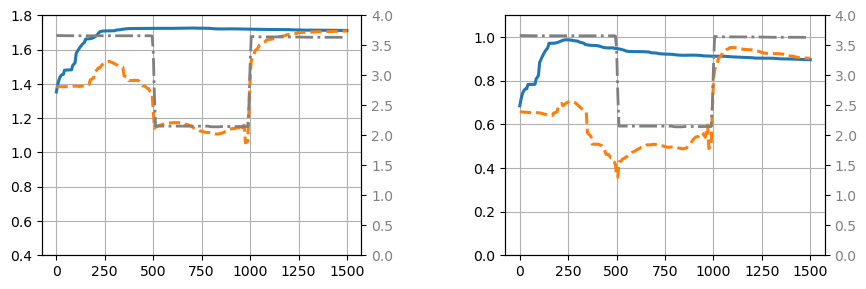

In [11]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# West-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Mean water depth
depth_reef_mean = np.nanmax(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

tick_size = 10

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(9, 3),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------

ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--"
)

ax_hs.set_ylim(0.4, 1.8)
ax_hs.grid(True)
ax_hs.tick_params(axis='both', labelsize=tick_size)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-."
)

ax_hs_depth.set_ylim(0, 4.0)
ax_hs_depth.tick_params(
    axis='y',
    labelsize=tick_size,
    labelcolor='gray'
)

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------

ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--"
)

ax_sxx.set_ylim(0, 1.1)
ax_sxx.grid(True)
ax_sxx.tick_params(axis='both', labelsize=tick_size)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-."
)

ax_sxx_depth.set_ylim(0, 4.0)
ax_sxx_depth.tick_params(
    axis='y',
    labelsize=tick_size,
    labelcolor='gray'
)

# =========================
# Layout
# =========================

plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.15,
    top=0.95,
    wspace=0.45
)

plt.show()

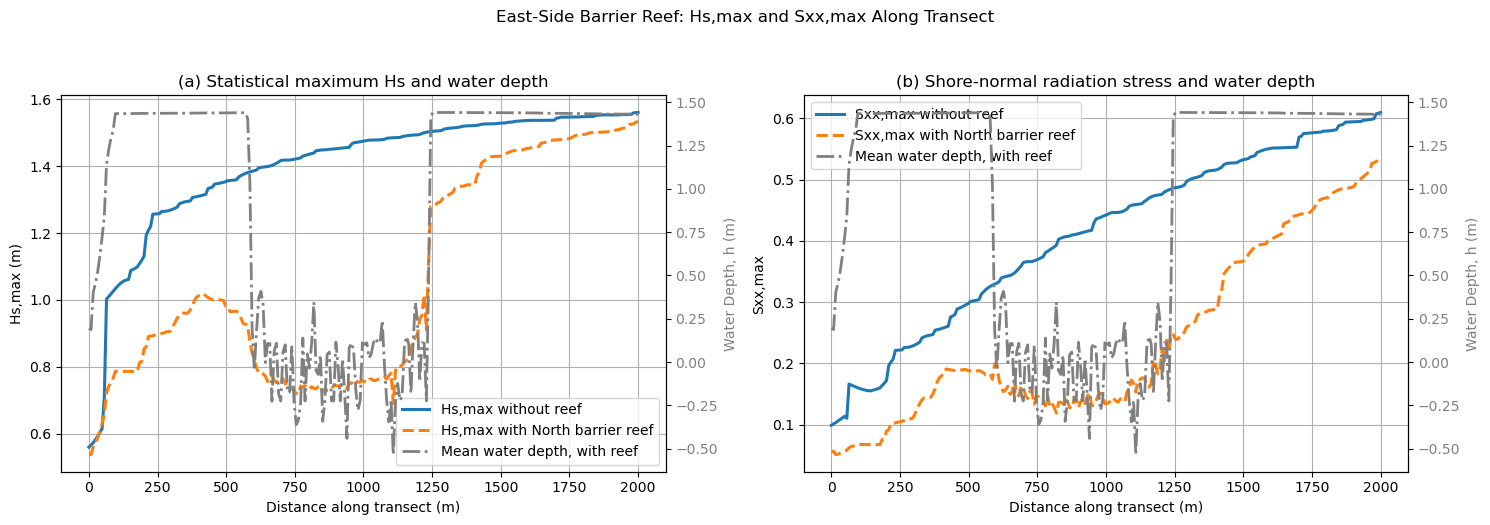

In [12]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# east-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 736598, 3177013
x2, y2 = 734827, 3176083

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "East-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

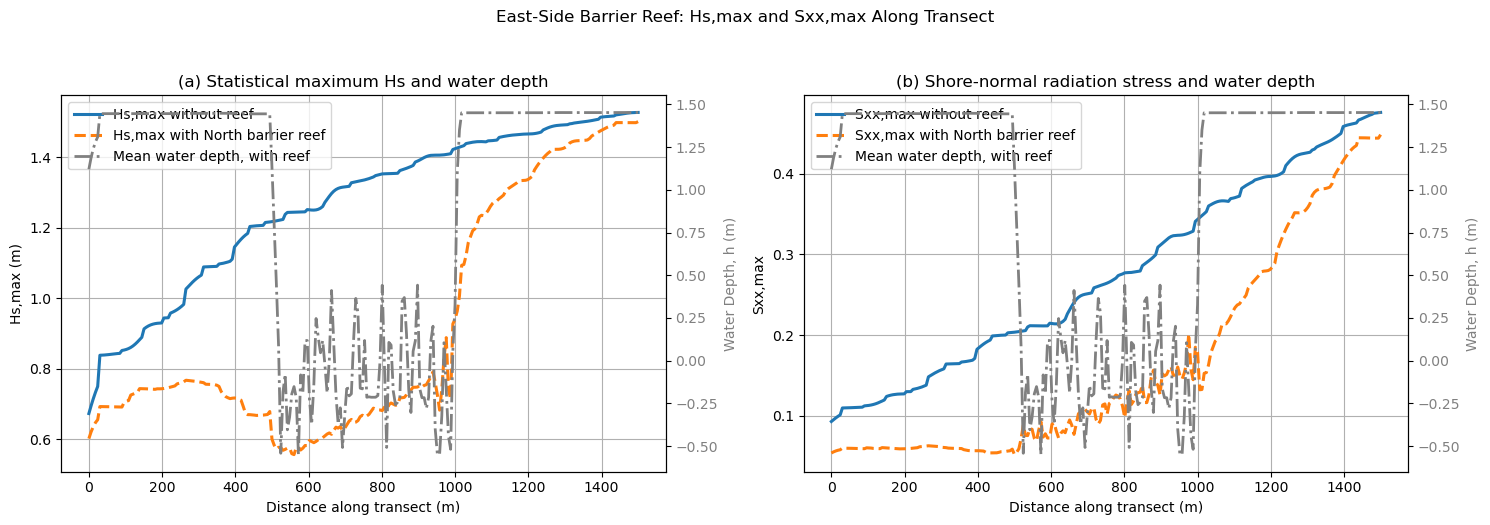

In [18]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# east-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_v1.sw - Result Files\east_side_reef_v1.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 736662, 3177738
x2, y2 = 735243, 3177252

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "East-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

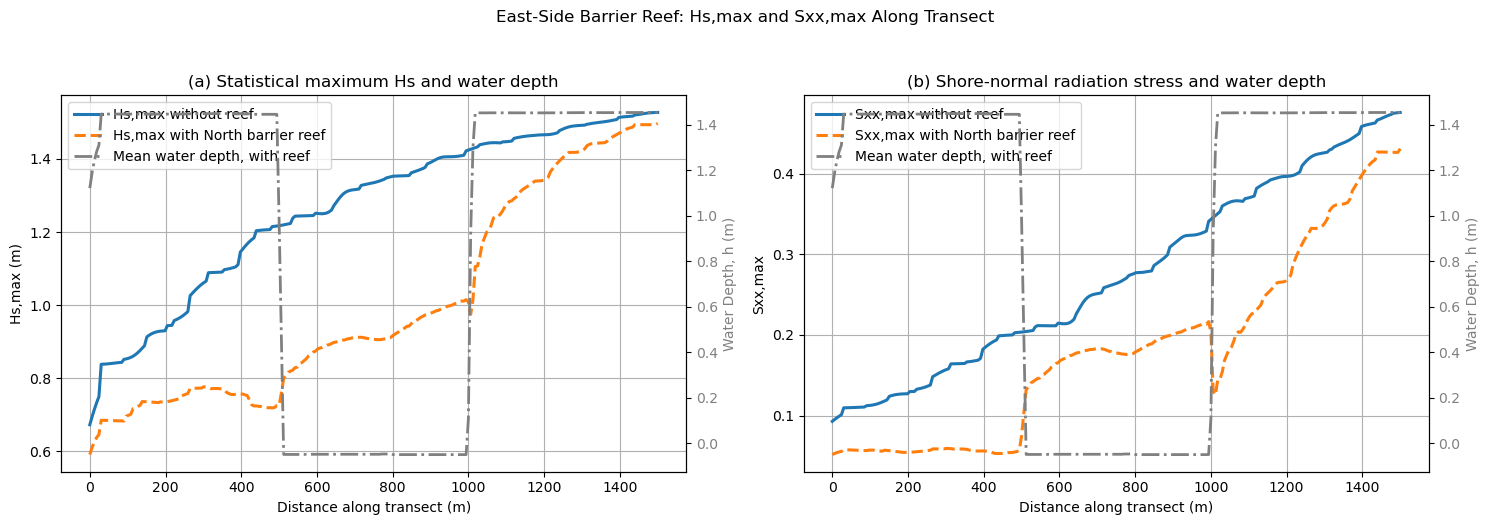

In [20]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# east-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 736662, 3177738
x2, y2 = 735243, 3177252

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "East-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

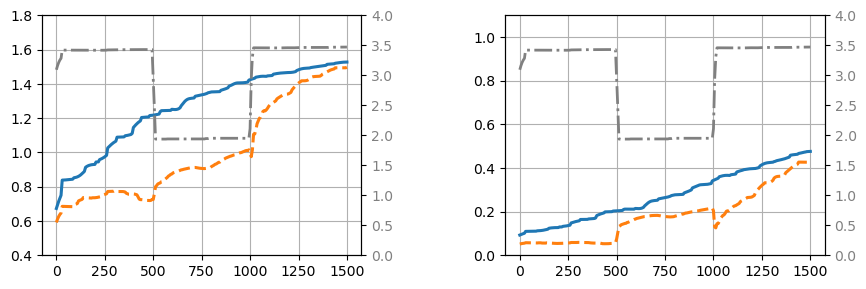

In [12]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# east-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 736662, 3177738
x2, y2 = 735243, 3177252

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Mean water depth
depth_reef_mean = np.nanmax(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

tick_size = 10

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(9, 3),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------

ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--"
)

ax_hs.set_ylim(0.4, 1.8)
ax_hs.grid(True)
ax_hs.tick_params(axis='both', labelsize=tick_size)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-."
)

ax_hs_depth.set_ylim(0, 4.0)
ax_hs_depth.tick_params(
    axis='y',
    labelsize=tick_size,
    labelcolor='gray'
)

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------

ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--"
)

ax_sxx.set_ylim(0, 1.1)
ax_sxx.grid(True)
ax_sxx.tick_params(axis='both', labelsize=tick_size)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-."
)

ax_sxx_depth.set_ylim(0, 4.0)
ax_sxx_depth.tick_params(
    axis='y',
    labelsize=tick_size,
    labelcolor='gray'
)
# =========================
# Layout
# =========================

plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.15,
    top=0.95,
    wspace=0.45
)

plt.show()

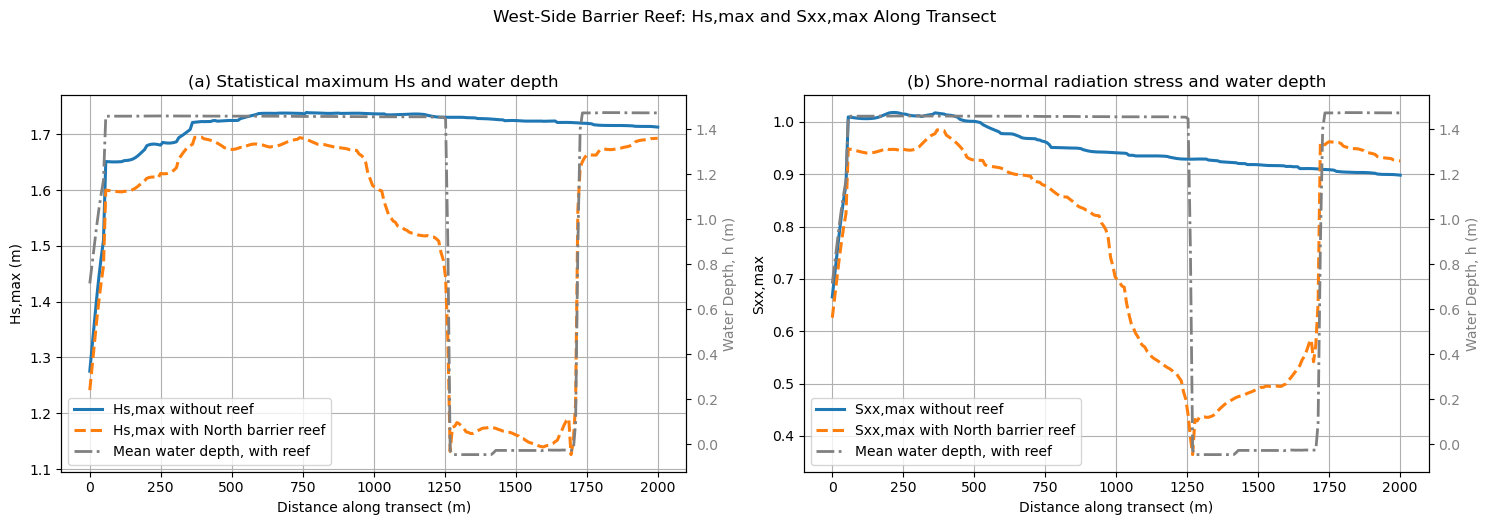

In [13]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_al_through_1.5m_height.sw - Result Files\small_scale_wave_result_with_barrier_reef_1.5m.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731549, 3175813

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "West-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

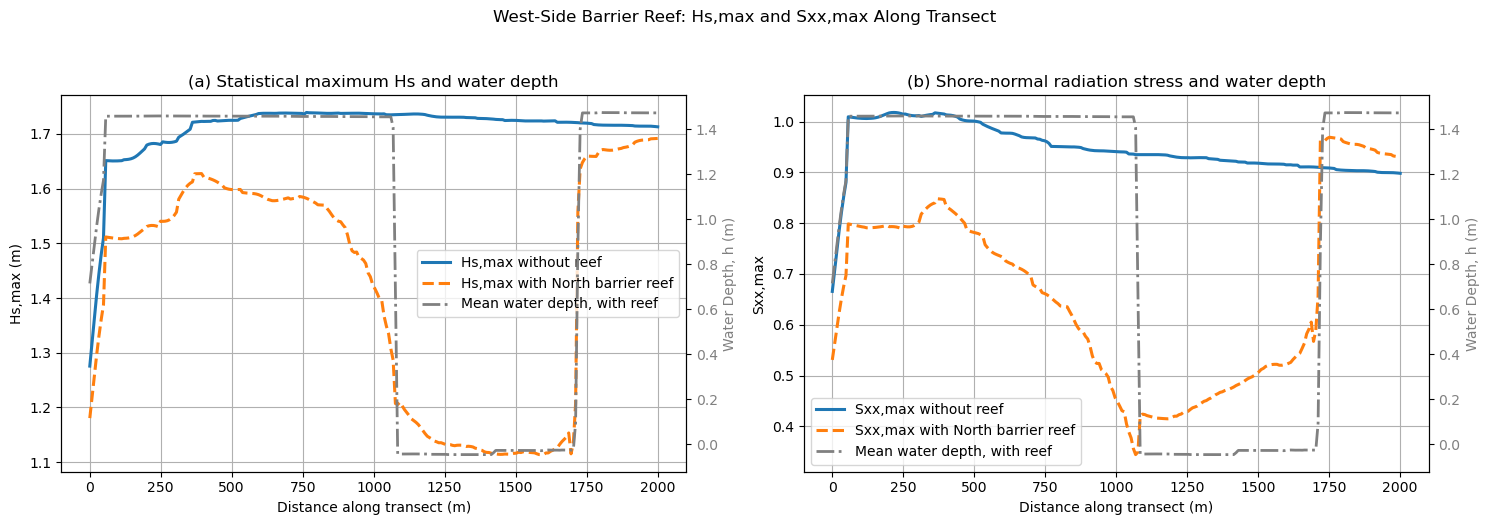

In [19]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# North-side barrier reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_al_through_1.5m_height.sw - Result Files\small_scale_wave_result_with_barrier_reef_1.5m_v1.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731549, 3175813

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Functions
# =========================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile_t = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile_t)

    return np.array(profiles), ds.time.values


# =========================
# Extract profiles
# =========================

# Hs
hs_reef_all, time_reef = extract_profile_all_times(
    dfsu_reef,
    "Sign. Wave Height"
)

hs_no_reef_all, time_no_reef = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

# Sxx
sxx_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Rad. Stress, Sxx"
)

sxx_no_reef_all, _ = extract_profile_all_times(
    dfsu_no_reef,
    "Rad. Stress, Sxx"
)

# Water depth from with-reef condition
depth_reef_all, _ = extract_profile_all_times(
    dfsu_reef,
    "Water depth"
)

# Statistical maximum over all timesteps
hsmax_reef = np.nanmax(hs_reef_all, axis=0)
hsmax_no_reef = np.nanmax(hs_no_reef_all, axis=0)

sxxmax_reef = np.nanmax(sxx_reef_all, axis=0)
sxxmax_no_reef = np.nanmax(sxx_no_reef_all, axis=0)

# Representative water depth from with-reef condition
# Using temporal mean because water depth may vary with surge/tide
depth_reef_mean = np.nanmean(depth_reef_all, axis=0)

# =========================
# Plot
# =========================

fig, (ax_hs, ax_sxx) = plt.subplots(
    1, 2,
    figsize=(15, 5),
    sharex=True
)

# -------------------------
# Panel (a): Hs,max + water depth
# -------------------------
ax_hs.plot(
    distance,
    hsmax_no_reef,
    linewidth=2.2,
    label="Hs,max without reef"
)

ax_hs.plot(
    distance,
    hsmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Hs,max with North barrier reef"
)

ax_hs.set_xlabel("Distance along transect (m)")
ax_hs.set_ylabel("Hs,max (m)")
ax_hs.grid(True)

ax_hs_depth = ax_hs.twinx()

ax_hs_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_hs_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_hs_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_hs.get_legend_handles_labels()
lines2, labels2 = ax_hs_depth.get_legend_handles_labels()

ax_hs.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_hs.set_title("(a) Statistical maximum Hs and water depth")

# -------------------------
# Panel (b): Sxx,max + water depth
# -------------------------
ax_sxx.plot(
    distance,
    sxxmax_no_reef,
    linewidth=2.2,
    label="Sxx,max without reef"
)

ax_sxx.plot(
    distance,
    sxxmax_reef,
    linewidth=2.2,
    linestyle="--",
    label="Sxx,max with North barrier reef"
)

ax_sxx.set_xlabel("Distance along transect (m)")
ax_sxx.set_ylabel("Sxx,max")
ax_sxx.grid(True)

ax_sxx_depth = ax_sxx.twinx()

ax_sxx_depth.plot(
    distance,
    depth_reef_mean,
    color="gray",
    linewidth=2,
    linestyle="-.",
    label="Mean water depth, with reef"
)

ax_sxx_depth.set_ylabel("Water Depth, h (m)", color="gray")
ax_sxx_depth.tick_params(axis="y", labelcolor="gray")

lines1, labels1 = ax_sxx.get_legend_handles_labels()
lines2, labels2 = ax_sxx_depth.get_legend_handles_labels()

ax_sxx.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

ax_sxx.set_title("(b) Shore-normal radiation stress and water depth")

plt.suptitle(
    "West-Side Barrier Reef: Hs,max and Sxx,max Along Transect",
    y=1.04
)

plt.tight_layout()
plt.show()

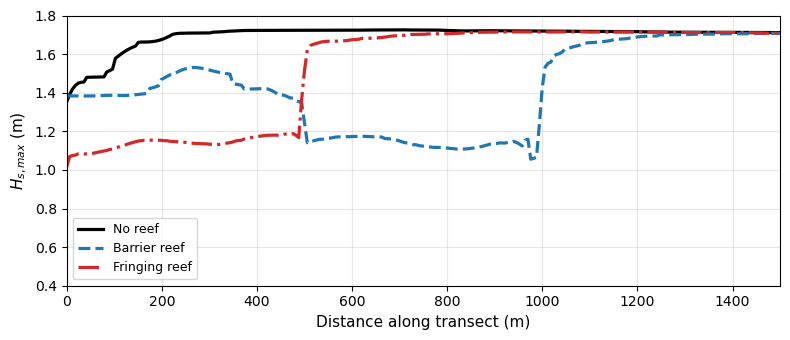

In [17]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# File paths
# ==========================================================

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

dfsu_barrier = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

dfsu_fringing = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu"

# ==========================================================
# Transect
# ==========================================================

x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# ==========================================================
# Function
# ==========================================================

def extract_profile_all_times(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile)

    return np.array(profiles)

# ==========================================================
# Extract significant wave height
# ==========================================================

hs_no = extract_profile_all_times(
    dfsu_no_reef,
    "Sign. Wave Height"
)

hs_barrier = extract_profile_all_times(
    dfsu_barrier,
    "Sign. Wave Height"
)

hs_fringing = extract_profile_all_times(
    dfsu_fringing,
    "Sign. Wave Height"
)

# ==========================================================
# Statistical maximum over all time steps
# ==========================================================

hs_no_max = np.nanmax(hs_no, axis=0)
hs_barrier_max = np.nanmax(hs_barrier, axis=0)
hs_fringing_max = np.nanmax(hs_fringing, axis=0)

# ==========================================================
# Plot
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(
    distance,
    hs_no_max,
    color="black",
    linewidth=2.3,
    label="No reef"
)

ax.plot(
    distance,
    hs_barrier_max,
    color="tab:blue",
    linestyle="--",
    linewidth=2.3,
    label="Barrier reef"
)

ax.plot(
    distance,
    hs_fringing_max,
    color="tab:red",
    linestyle="-.",
    linewidth=2.3,
    label="Fringing reef"
)

ax.set_xlim(distance.min(), distance.max())
ax.set_ylim(0.4, 1.8)

ax.set_xlabel("Distance along transect (m)", fontsize=11)
ax.set_ylabel(r"$H_{s,max}$ (m)", fontsize=11)

ax.tick_params(axis="both", labelsize=10)
ax.grid(True, alpha=0.3)

# Legend only for Hs curves
ax.legend(
    loc="best",
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

No-reef array shape: (229, 250)
Barrier-reef array shape: (229, 250)
Fringing-reef array shape: (229, 250)


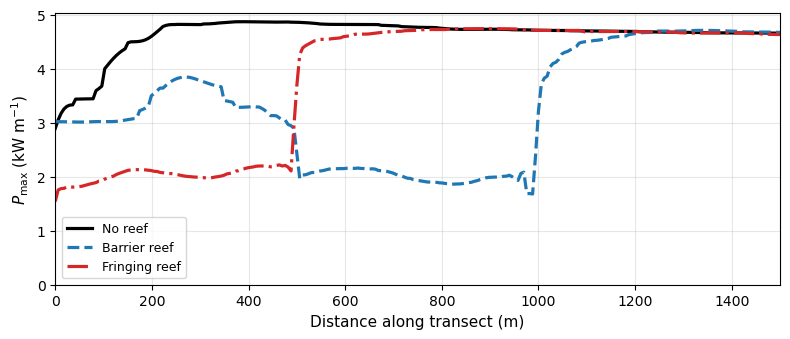

In [19]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# File paths
# ==========================================================

dfsu_no_reef = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files"
    r"\small_scale_wave_result.dfsu"
)

dfsu_barrier = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_barrier_reef_1.5m_v2.sw - Result Files"
    r"\west_side_barrier_reef_1.5m_v2.dfsu"
)

dfsu_fringing = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_fringing_reef_v1.sw - Result Files"
    r"\west_side_fringing_reef_1.5m_v2.dfsu"
)

# ==========================================================
# Transect
# ==========================================================

x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack((x_line, y_line))

distance = np.sqrt(
    (x_line - x_line[0]) ** 2
    + (y_line - y_line[0]) ** 2
)

# ==========================================================
# Function to extract transect profile for all time steps
# ==========================================================

def extract_profile_all_times(dfsu_file, item_name):
    """
    Extract an interpolated transect profile from every time step
    in a MIKE 21 SW DFSU file.

    Returns
    -------
    profiles : ndarray
        Shape = (number of time steps, number of transect points)
    time : pandas.DatetimeIndex
        Time axis from the DFSU file
    """

    dfs = mikeio.open(dfsu_file)

    # Check item names before reading
    available_items = [item.name for item in dfs.items]

    if item_name not in available_items:
        raise ValueError(
            f"\nItem '{item_name}' was not found in:\n{dfsu_file}\n\n"
            f"Available items are:\n"
            + "\n".join(available_items)
        )

    ds = dfs.read(items=[item_name])
    da = ds[item_name]

    # Calculate interpolation information once
    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profiles = []

    for t in range(len(ds.time)):
        da_t = da.isel(time=t)

        profile = da_t.geometry.interp2d(
            da_t,
            elem_ids,
            weights
        ).flatten()

        profiles.append(profile)

    return np.asarray(profiles), ds.time


# ==========================================================
# Extract wave power
# ==========================================================

item_name = "Wave power, p"

power_no, time_no = extract_profile_all_times(
    dfsu_no_reef,
    item_name
)

power_barrier, time_barrier = extract_profile_all_times(
    dfsu_barrier,
    item_name
)

power_fringing, time_fringing = extract_profile_all_times(
    dfsu_fringing,
    item_name
)

# ==========================================================
# Verify time dimensions
# ==========================================================

print("No-reef array shape:", power_no.shape)
print("Barrier-reef array shape:", power_barrier.shape)
print("Fringing-reef array shape:", power_fringing.shape)

# ==========================================================
# Statistical maximum over all time steps
# ==========================================================

power_no_max = np.nanmax(power_no, axis=0)
power_barrier_max = np.nanmax(power_barrier, axis=0)
power_fringing_max = np.nanmax(power_fringing, axis=0)

# ==========================================================
# Optional conversion from W/m to kW/m
# ==========================================================

# convert_to_kw = True

# if convert_to_kw:
#     power_no_max = power_no_max / 1000.0
#     power_barrier_max = power_barrier_max / 1000.0
#     power_fringing_max = power_fringing_max / 1000.0

#     y_label = r"$P_{\max}$ (kW m$^{-1}$)"
# else:
#     y_label = r"$P_{\max}$ (W m$^{-1}$)"

# ==========================================================
# Plot
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(
    distance,
    power_no_max,
    color="black",
    linewidth=2.3,
    label="No reef"
)

ax.plot(
    distance,
    power_barrier_max,
    color="tab:blue",
    linestyle="--",
    linewidth=2.3,
    label="Barrier reef"
)

ax.plot(
    distance,
    power_fringing_max,
    color="tab:red",
    linestyle="-.",
    linewidth=2.3,
    label="Fringing reef"
)

ax.set_xlim(distance.min(), distance.max())

# Use automatic y-axis limits because wave-power magnitude
# depends on the model results
ax.set_ylim(bottom=0)

ax.set_xlabel(
    "Distance along transect (m)",
    fontsize=11
)

ax.set_ylabel(
    y_label,
    fontsize=11
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend(
    loc="best",
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

Transect length: 1499.86 m

Opening file:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu
Extracted profile array shape: (229, 250)

Opening file:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu
Extracted profile array shape: (229, 250)

Opening file:
D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu
Extracted profile array shape: (229, 250)

Array dimensions
No-reef array shape: (229, 250)
Barrier-reef array shape: (229, 250)
Fringing-reef array shape: (229, 250)


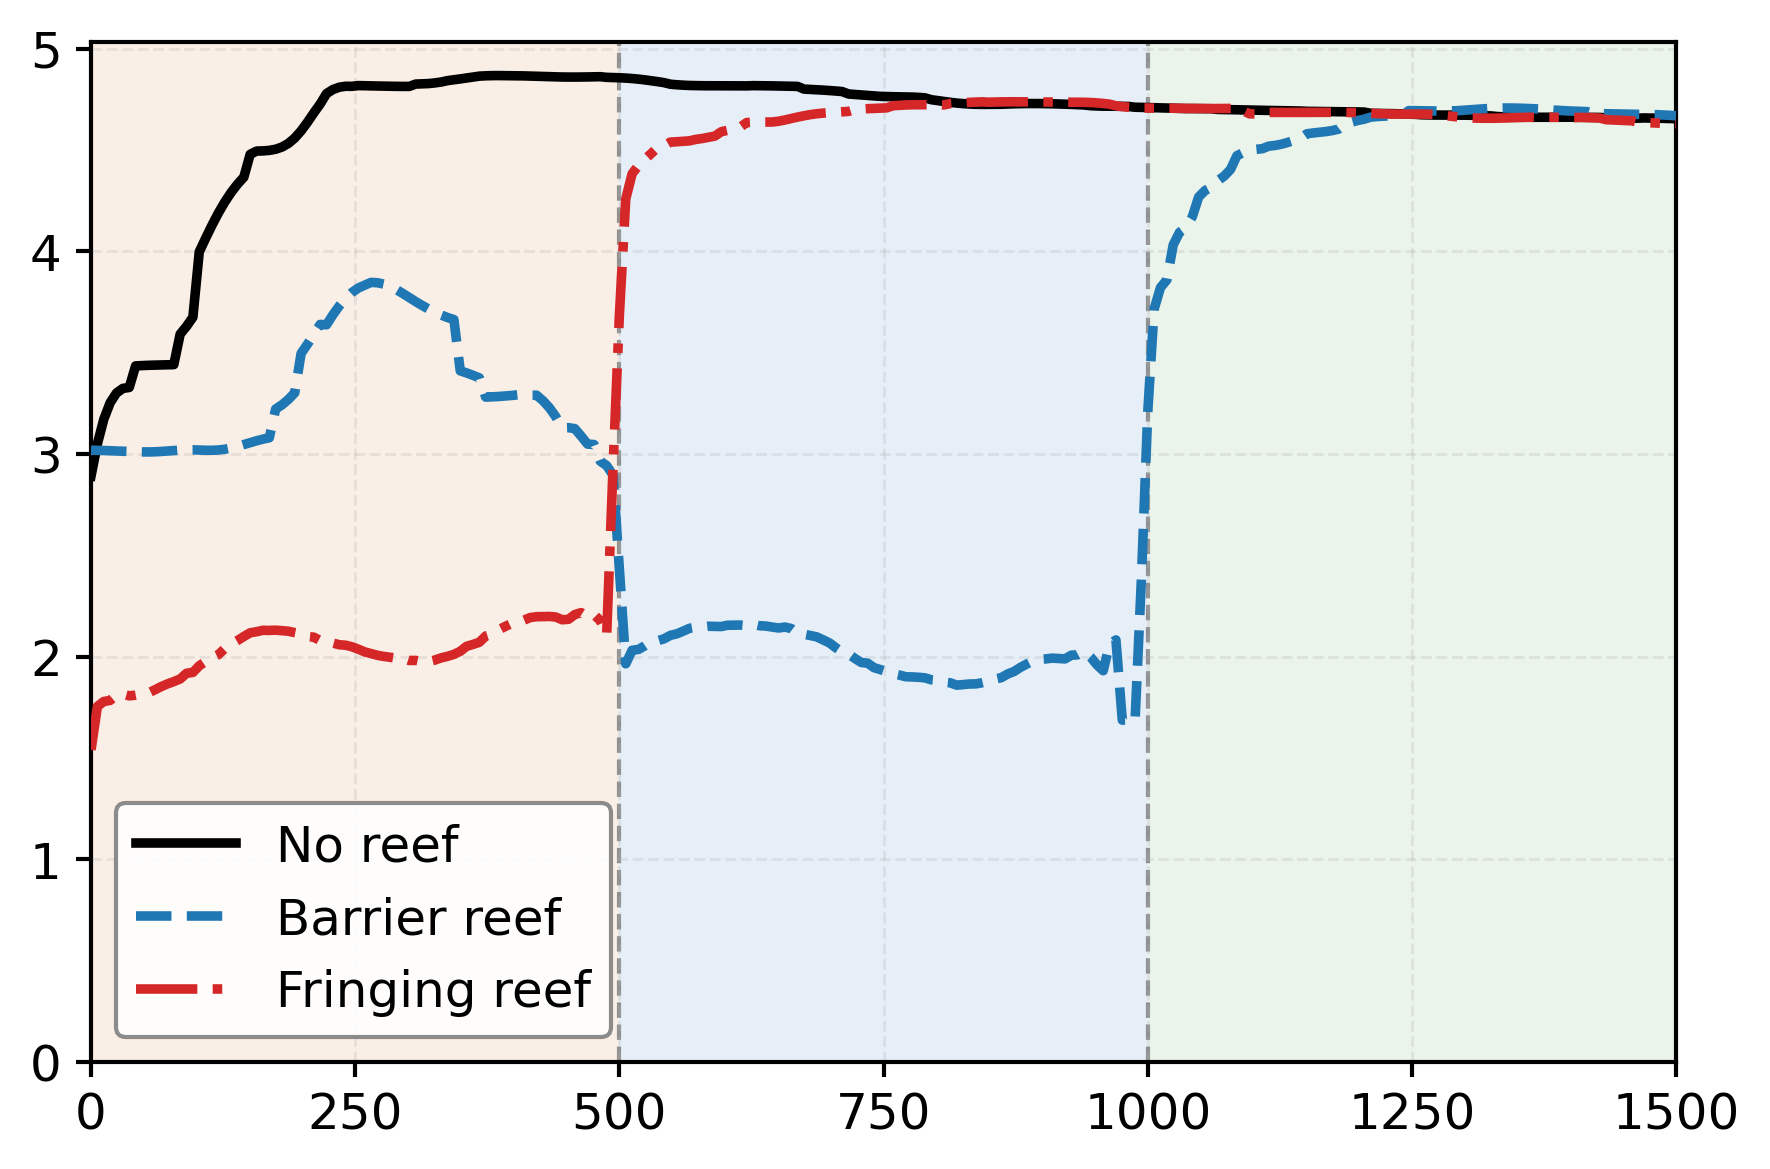

In [26]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# File paths
# ==========================================================

dfsu_no_reef = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files"
    r"\small_scale_wave_result.dfsu"
)

dfsu_barrier = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_barrier_reef_1.5m_v2.sw - Result Files"
    r"\west_side_barrier_reef_1.5m_v2.dfsu"
)

dfsu_fringing = (
    r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation"
    r"\West_side_fringing_reef_v1.sw - Result Files"
    r"\west_side_fringing_reef_1.5m_v2.dfsu"
)

# ==========================================================
# Transect
# ==========================================================

x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 250

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)

coords = np.column_stack(
    (x_line, y_line)
)

distance = np.sqrt(
    (x_line - x_line[0]) ** 2
    + (y_line - y_line[0]) ** 2
)

print(
    f"Transect length: {distance[-1]:.2f} m"
)

# ==========================================================
# Function to extract transect profiles for all timesteps
# ==========================================================

def extract_profile_all_times(
    dfsu_file,
    item_name
):
    """
    Extract an interpolated transect profile from every timestep
    in a MIKE 21 SW DFSU file.

    Returns
    -------
    profiles : numpy.ndarray
        Array with shape:
        number of timesteps × number of transect points

    time : pandas.DatetimeIndex
        Time values from the DFSU file
    """

    print("\n" + "=" * 70)
    print(f"Opening file:\n{dfsu_file}")
    print("=" * 70)

    dfs = mikeio.open(
        dfsu_file
    )

    available_items = [
        item.name
        for item in dfs.items
    ]

    if item_name not in available_items:
        raise ValueError(
            f"\nItem '{item_name}' was not found in:\n"
            f"{dfsu_file}\n\n"
            f"Available items are:\n"
            + "\n".join(available_items)
        )

    ds = dfs.read(
        items=[item_name]
    )

    da = ds[item_name]

    # Calculate interpolation information once
    elem_ids, weights = (
        da.geometry.get_2d_interpolant(
            coords,
            n_nearest=3,
            extrapolate=False
        )
    )

    profiles = []

    for t in range(len(ds.time)):

        da_t = da.isel(
            time=t
        )

        profile = da_t.geometry.interp2d(
            da_t,
            elem_ids=elem_ids,
            weights=weights
        )

        profile = np.asarray(
            profile
        ).flatten()

        # Replace MIKE delete values with NaN
        profile[
            np.abs(profile) > 1.0e30
        ] = np.nan

        profiles.append(
            profile
        )

    profiles = np.asarray(
        profiles,
        dtype=float
    )

    print(
        f"Extracted profile array shape: "
        f"{profiles.shape}"
    )

    return profiles, ds.time


# ==========================================================
# Extract wave power
# ==========================================================

item_name = "Wave power, p"

power_no, time_no = extract_profile_all_times(
    dfsu_file=dfsu_no_reef,
    item_name=item_name
)

power_barrier, time_barrier = extract_profile_all_times(
    dfsu_file=dfsu_barrier,
    item_name=item_name
)

power_fringing, time_fringing = extract_profile_all_times(
    dfsu_file=dfsu_fringing,
    item_name=item_name
)

# ==========================================================
# Verify dimensions
# ==========================================================

print("\nArray dimensions")
print(
    "No-reef array shape:",
    power_no.shape
)

print(
    "Barrier-reef array shape:",
    power_barrier.shape
)

print(
    "Fringing-reef array shape:",
    power_fringing.shape
)

# Check that all profile arrays have the same number of points
if not (
    power_no.shape[1]
    == power_barrier.shape[1]
    == power_fringing.shape[1]
    == n_points
):
    raise ValueError(
        "The transect profile arrays do not contain "
        "the same number of spatial points."
    )

# ==========================================================
# Statistical maximum over all timesteps
# ==========================================================

power_no_max = np.nanmax(
    power_no,
    axis=0
)

power_barrier_max = np.nanmax(
    power_barrier,
    axis=0
)

power_fringing_max = np.nanmax(
    power_fringing,
    axis=0
)

# print("\nMaximum wave-power values")

# print(
#     f"No reef maximum: "
#     f"{np.nanmax(power_no_max):.3f}"
# )

# print(
#     f"Barrier reef maximum: "
#     f"{np.nanmax(power_barrier_max):.3f}"
# )

# print(
#     f"Fringing reef maximum: "
#     f"{np.nanmax(power_fringing_max):.3f}"
# )

# ==========================================================
# Plot settings
# ==========================================================

# The model output is already in kW/m.
y_label = r"$P_{\max}$ (kW m$^{-1}$)"

# Distance-zone boundaries
zone_1_start = 0
zone_1_end = 500

zone_2_start = 500
zone_2_end = 1000

zone_3_start = 1000
zone_3_end = 1500

# ==========================================================
# Plot
# ==========================================================

fig, ax = plt.subplots(
    figsize=(6, 4),
    dpi=300
)

# ----------------------------------------------------------
# Shaded distance zones
# ----------------------------------------------------------

ax.axvspan(
    zone_1_start,
    zone_1_end,
    facecolor="#F6DCC8",
    alpha=0.45,
    zorder=0
)

ax.axvspan(
    zone_2_start,
    zone_2_end,
    facecolor="#CFE1F2",
    alpha=0.50,
    zorder=0
)

ax.axvspan(
    zone_3_start,
    zone_3_end,
    facecolor="#D8EBD8",
    alpha=0.50,
    zorder=0
)

# ----------------------------------------------------------
# Vertical zone boundaries
# ----------------------------------------------------------

ax.axvline(
    zone_1_end,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    alpha=0.85,
    zorder=1
)

ax.axvline(
    zone_2_end,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    alpha=0.85,
    zorder=1
)

# ----------------------------------------------------------
# Wave-power profiles
# ----------------------------------------------------------

ax.plot(
    distance,
    power_no_max,
    color="black",
    linewidth=2.3,
    linestyle="-",
    label="No reef",
    zorder=3
)

ax.plot(
    distance,
    power_barrier_max,
    color="tab:blue",
    linewidth=2.3,
    linestyle="--",
    label="Barrier reef",
    zorder=3
)

ax.plot(
    distance,
    power_fringing_max,
    color="tab:red",
    linewidth=2.3,
    linestyle="-.",
    label="Fringing reef",
    zorder=3
)

# ==========================================================
# Axis formatting
# ==========================================================

# Use the actual transect length, but limit to 1500 m
plot_max_distance = min(
    1500,
    distance[-1]
)

ax.set_xlim(
    0,
    plot_max_distance
)

ax.set_ylim(
    bottom=0
)

ax.set_xticks(
    np.arange(
        0,
        plot_max_distance + 1,
        250
    )
)

# ax.set_xlabel(
#     "Distance along transect, x (m)",
#     fontsize=12,
#     fontweight="bold"
# )

# ax.set_ylabel(
#     y_label,
#     fontsize=12,
#     fontweight="bold"
# )

ax.tick_params(
    axis="both",
    labelsize=12,
    direction="out",
    width=1.0
)

# ==========================================================
# Grid and legend
# ==========================================================

ax.grid(
    True,
    axis="both",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    zorder=0
)

ax.legend(
    loc="best",
    fontsize=12,
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=0.9
)

# ==========================================================
# Axis border formatting
# ==========================================================

for spine in ax.spines.values():
    spine.set_linewidth(
        1.0
    )

# ==========================================================
# Layout, save, and display
# ==========================================================

plt.tight_layout()
plt.show()

# print(
#     f"\nFigure saved to:\n{output_figure}"
# )